# HOTAIR Conservation and Covariation Analysis

## Date:

Start: November 20, 2025

Last Updated: May 15, 2026

## Purpose:

For Perry et al. 2026.

Bioinformatics analysis of HOTAIR conservation and covariation in primate genomes.

This code is provided as-is for reproducibility purposes and may be reused freely under the MIT License. No guarantees are made regarding functionality in other environments or use cases.

# Pipeline

## Installations

In [1]:
conda install -c conda-forge biopython

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - conda-forge
 - bioconda
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [2]:
conda install -c conda-forge matplotlib

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - conda-forge
 - bioconda
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [8]:
conda install bioconda::easel

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - bioconda
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import re
# Biopython
from Bio import AlignIO, SeqIO
from Bio.Align import MultipleSeqAlignment
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

## Functions

In [5]:
# Process R-scape output positions to convert to the correct nucleotide coordinate in the ungapped sequence
def process_rscape_positions(positions_file, gapped_sequence, output_file):
    """
    Process R-scape positions and convert to ungapped coordinates.
    
    Args:
        positions_file: path to text file with two columns (left_pos, right_pos)
        gapped_sequence: string containing the gapped alignment sequence
        output_file: path to save output CSV
    
    Returns:
        DataFrame with 5 columns: left_pos, right_pos, left_pos_ungapped, 
        right_pos_ungapped, nucleotide (format: "left_nt:right_nt")
    """
    # Read the positions file (assumes tab separated)
    df = pd.read_csv(positions_file, sep='\t', skiprows=1, header=None, names=['left_pos', 'right_pos'])
    
    # Process each row
    results = []
    for idx, row in df.iterrows():
        left_pos = int(row['left_pos'])
        right_pos = int(row['right_pos'])
        
        # Convert left position to ungapped
        left_idx = left_pos - 1
        left_nt = gapped_sequence[left_idx]
        left_substring = gapped_sequence[:left_pos]
        left_ungapped = len(left_substring.replace('-', ''))
        
        # Convert right position to ungapped
        right_idx = right_pos - 1
        right_nt = gapped_sequence[right_idx]
        right_substring = gapped_sequence[:right_pos]
        right_ungapped = len(right_substring.replace('-', ''))
        
        # Format nucleotide as "left:right"
        nucleotide = f"{left_nt}:{right_nt}"
        
        results.append({
            'left_pos': left_pos,
            'right_pos': right_pos,
            'left_pos_ungapped': left_ungapped,
            'right_pos_ungapped': right_ungapped,
            'nucleotide': nucleotide
        })
    
    result_df = pd.DataFrame(results)
    
    # Save to output file
    result_df.to_csv(output_file, sep='\t', index=False)
    print(f"Results saved to {output_file}")
    print(f"Processed {len(result_df)} position pairs")
    
    return result_df


In [7]:
# Convert esl-alistat scores to per-nucleotide scores in the ungapped HOTAIR sequence
def map_ic_to_reference(alignment_file, icinfo_file):
    # 1. Read alignment
    aln = AlignIO.read(alignment_file, "clustal")
    ref_seq = aln[0].seq  # top sequence as reference, including gaps
    
    # 2. Read esl-alistat file
    df = pd.read_csv(icinfo_file, comment="#", sep="\\s+", names=["alnpos","freqnongap","info(bits)"])
    
    # 3. Map alignment columns → ungapped nucleotide positions
    ref_positions = []
    ungapped_pos = 0
    
    for col_idx, nt in enumerate(ref_seq):
        if nt != "-":
            ungapped_pos += 1
            ref_positions.append(ungapped_pos)
        else:
            ref_positions.append(None)   # gap → no nucleotide
    
    df["ref_nt"] = ref_positions
    
    # 4. Drop rows where reference has a gap (i.e., no nucleotide)
    df_nt = df.dropna(subset=["ref_nt"]).copy()
    df_nt["ref_nt"] = df_nt["ref_nt"].astype(int)
    
    return df_nt

## Step 1. Genome Searches

### 1.1 Full-length Search

Searching each genome with the full-length HOTAIR sequence produced a poor quality alignment and is only included here for completion

In [9]:
!esl-alistat --icinfo Data_input/Bioinformatics_Pipeline/Step_1_Genome_Searches/1.1_Full-length_Search/HOTAIR_MSA_191_icinfo.txt Data_input/Bioinformatics_Pipeline/Step_1_Genome_Searches/1.1_Full-length_Search/HOTAIR_MSA_191.aln

Alignment number:    1
Format:              Clustal
Number of sequences: 191
Alignment length:    5114
Total # residues:    394985
Smallest:            1265
Largest:             2148
Average length:      2068.0
Average identity:    51%
//
# Information content data saved to file Data_input/Bioinformatics_Pipeline/Step_1_Genome_Searches/1.1_Full-length_Search/HOTAIR_MSA_191_icinfo.txt.


In [17]:
# Warning: Remove '//' in icinfo.txt file before proceeding

In [10]:
alignment_file = "Data_input/Bioinformatics_Pipeline/Step_1_Genome_Searches/1.1_Full-length_Search/HOTAIR_MSA_191.aln"
icinfo_file = "Data_input/Bioinformatics_Pipeline/Step_1_Genome_Searches/1.1_Full-length_Search/HOTAIR_MSA_191_icinfo.txt"
df_nt_191 = map_ic_to_reference(alignment_file, icinfo_file)
window = 21  # must be odd for symmetric windows
df_nt_191["info_rolling"] = df_nt_191["info(bits)"].rolling(window, center=True).mean()
df_nt_191["freqnongap_rolling"] = df_nt_191["freqnongap"].rolling(window, center=True).mean()

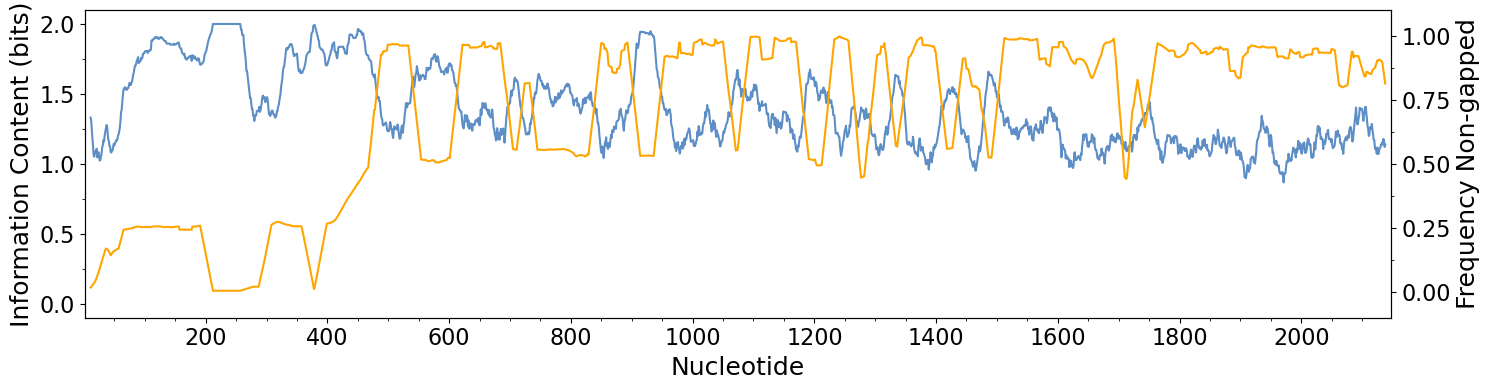

In [11]:
fig, ax1 = plt.subplots(figsize=(15, 4))

# Plot conservation
ax1.plot(df_nt_191["ref_nt"], df_nt_191["info_rolling"], linewidth=1.5, color="#5D8EC6", label="Information Content (bits)")
ax1.set_xlabel("Nucleotide", fontsize=18)
ax1.set_ylabel("Information Content (bits)", fontsize=18)
ax1.set_xlim(1, 2148)
ax1.set_ylim(-0.1, 2.1)
# ax1.set_xlim(0,1046)

# Plot frequency non-gapped
ax2 = ax1.twinx()
ax2.plot(df_nt_191["ref_nt"], df_nt_191["freqnongap_rolling"], linewidth=1.5, color="Orange", label="Frequency Non-gapped")
ax2.set_ylabel("Frequency Non-gapped", fontsize=18)
ax2.set_ylim(-0.1, 1.1)

# Ticks
ax1.tick_params(axis='x', labelsize=16)
ax1.tick_params(axis='y', labelsize=16)
ax2.tick_params(axis='y', labelsize=16)
ax1.xaxis.set_major_locator(MultipleLocator(200))  # major ticks
ax1.xaxis.set_minor_locator(MultipleLocator(50))  # minor ticks
ax1.yaxis.set_minor_locator(MultipleLocator(0.25))  # major ticks
ax2.yaxis.set_minor_locator(MultipleLocator(0.125))  # minor ticks

plt.tight_layout()
# plt.savefig("INSERT/PATH/TO/SAVE/HOTAIR_191_IC_FNG_rolling_w21.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

### 1.2 Exon-aware Searches

Searching each genome with exon groupings (exons 2-4, exons 4-6, exon 7) allowed construction of the full alignment of HOTAIR. The resulting MSAs for each exon grouping is included in its corresponding subfolder.

## Step 2. Scaffold Validation

### 2.1_Scaffold_Checks

For each species, we validated that the top hit for each of the exon-aware searches was located on the same scaffold. If not, that species was removed from subsequent steps.

### 2.2_MSAs_of_Exons_on_Same_Scaffold

The sequences that passed the scaffold check (179 non-human primate species + hHOTAIR) were aligned to generate MSAs for each exon grouping. A subalignment of just exons 5 and 6 was extracted from the MSA with exons 4-6.

### 2.3_Conservation_Results

Conservation was assessed for each column in each alignment. Later, only conservation values corresponding to nucleotides in hHOTAIR will be extracted.

#### Exons 2-4

In [13]:
!esl-alistat --icinfo Data_input/Bioinformatics_Pipeline/Step_2_Scaffold_Validation/2.3_Conservation_Results/HOTAIR_exons2-4_MSA_same_scaffold_icinfo.txt Data_input/Bioinformatics_Pipeline/Step_2_Scaffold_Validation/2.2_MSAs_of_Exons_on_Same_Scaffold/HOTAIR_exons2-4_MSA_same_scaffold.aln

Alignment number:    1
Format:              Clustal
Number of sequences: 180
Alignment length:    12117
Total # residues:    425598
Smallest:            117
Largest:             11817
Average length:      2364.4
Average identity:    89%
//
# Information content data saved to file Data_input/Bioinformatics_Pipeline/Step_2_Scaffold_Validation/2.3_Conservation_Results/HOTAIR_exons2-4_MSA_same_scaffold_icinfo.txt.


#### Exons 5-6

In [14]:
!esl-alistat --icinfo Data_input/Bioinformatics_Pipeline/Step_2_Scaffold_Validation/2.3_Conservation_Results/HOTAIR_exons5-6_MSA_same_scaffold_subalign_icinfo.txt Data_input/Bioinformatics_Pipeline/Step_2_Scaffold_Validation/2.2_MSAs_of_Exons_on_Same_Scaffold/HOTAIR_exons5-6_MSA_same_scaffold_subalign.aln

Alignment number:    1
Format:              Clustal
Number of sequences: 180
Alignment length:    2039
Total # residues:    330955
Smallest:            177
Largest:             1873
Average length:      1838.6
Average identity:    90%
//
# Information content data saved to file Data_input/Bioinformatics_Pipeline/Step_2_Scaffold_Validation/2.3_Conservation_Results/HOTAIR_exons5-6_MSA_same_scaffold_subalign_icinfo.txt.


#### Exon 7

In [15]:
!esl-alistat --icinfo Data_input/Bioinformatics_Pipeline/Step_2_Scaffold_Validation/2.3_Conservation_Results/HOTAIR_exon7_MSA_same_scaffold_icinfo.txt Data_input/Bioinformatics_Pipeline/Step_2_Scaffold_Validation/2.2_MSAs_of_Exons_on_Same_Scaffold/HOTAIR_exon7_MSA_same_scaffold.aln

Alignment number:    1
Format:              Clustal
Number of sequences: 180
Alignment length:    2335
Total # residues:    325370
Smallest:            832
Largest:             2064
Average length:      1807.6
Average identity:    87%
//
# Information content data saved to file Data_input/Bioinformatics_Pipeline/Step_2_Scaffold_Validation/2.3_Conservation_Results/HOTAIR_exon7_MSA_same_scaffold_icinfo.txt.


#### Plot Conservation of Exon-groupings

In [16]:
# Warning: Remove '//' in icinfo.txt files before proceeding

In [17]:
alignment_file = "Data_input/Bioinformatics_Pipeline/Step_2_Scaffold_Validation/2.2_MSAs_of_Exons_on_Same_Scaffold/HOTAIR_exons2-4_MSA_same_scaffold.aln"
icinfo_file = "Data_input/Bioinformatics_Pipeline/Step_2_Scaffold_Validation/2.3_Conservation_Results/HOTAIR_exons2-4_MSA_same_scaffold_icinfo.txt"
df_nt_exons2_4 = map_ic_to_reference(alignment_file, icinfo_file)

In [18]:
alignment_file = "Data_input/Bioinformatics_Pipeline/Step_2_Scaffold_Validation/2.2_MSAs_of_Exons_on_Same_Scaffold/HOTAIR_exons5-6_MSA_same_scaffold_subalign.aln"
icinfo_file = "Data_input/Bioinformatics_Pipeline/Step_2_Scaffold_Validation/2.3_Conservation_Results/HOTAIR_exons5-6_MSA_same_scaffold_subalign_icinfo.txt"
df_nt_exons5_6 = map_ic_to_reference(alignment_file, icinfo_file)

In [19]:
alignment_file = "Data_input/Bioinformatics_Pipeline/Step_2_Scaffold_Validation/2.2_MSAs_of_Exons_on_Same_Scaffold/HOTAIR_exon7_MSA_same_scaffold.aln"
icinfo_file = "Data_input/Bioinformatics_Pipeline/Step_2_Scaffold_Validation/2.3_Conservation_Results/HOTAIR_exon7_MSA_same_scaffold_icinfo.txt"
df_nt_exon7 = map_ic_to_reference(alignment_file, icinfo_file)

In [20]:
print(df_nt_exons2_4.shape)
print(df_nt_exons5_6.shape)
print(df_nt_exon7.shape)

(288, 4)
(177, 4)
(1683, 4)


In [21]:
# check dataframe
df_nt_exons2_4.head(10)

,alnpos,freqnongap,info(bits),ref_nt
0,1,0.866667,1.632166,1
1,2,0.961111,1.404074,2
2,3,0.961111,1.389437,3
3,4,0.961111,1.354090,4
4,5,0.961111,0.942877,5
5,6,0.961111,1.729783,6
6,7,0.961111,1.555288,7
7,8,0.961111,1.841375,8
8,9,0.961111,2.000000,9
9,10,0.961111,1.948710,10


In [22]:
# Define the offset nt for each exon grouping
offset2 = 288
offset3 = 465

df_nt_exons2_4["real_nt"] = df_nt_exons2_4["ref_nt"]
df_nt_exons5_6["real_nt"] = df_nt_exons5_6["ref_nt"] + offset2
df_nt_exon7["real_nt"] = df_nt_exon7["ref_nt"] + offset3

# Concatenate into one dataframe for plotting
df_HOTAIR_exons_combined = pd.concat([df_nt_exons2_4, df_nt_exons5_6, df_nt_exon7], ignore_index=True)

In [23]:
# check dataframe
df_HOTAIR_exons_combined.tail(10)

,alnpos,freqnongap,info(bits),ref_nt,real_nt
2138,2326,0.972222,1.029049,1674,2139
2139,2327,0.972222,1.792197,1675,2140
2140,2328,0.972222,1.812824,1676,2141
2141,2329,0.977778,1.440695,1677,2142
2142,2330,0.977778,1.949443,1678,2143
2143,2331,0.977778,1.949443,1679,2144
2144,2332,0.977778,2.000000,1680,2145
2145,2333,0.972222,2.000000,1681,2146
2146,2334,0.972222,1.842805,1682,2147
2147,2335,0.972222,1.949201,1683,2148


In [24]:
window = 21  # must be odd for symmetric windows
df_HOTAIR_exons_combined["info_rolling"] = df_HOTAIR_exons_combined["info(bits)"].rolling(window, center=True).mean()
df_HOTAIR_exons_combined["freqnongap_rolling"] = df_HOTAIR_exons_combined["freqnongap"].rolling(window, center=True).mean()

In [25]:
df_HOTAIR_exons_combined.tail(50)

,alnpos,freqnongap,info(bits),ref_nt,real_nt,info_rolling,freqnongap_rolling
2098,2280,0.977778,2.000000,1634,2099,1.766027,0.967725
2099,2281,0.977778,2.000000,1635,2100,1.766027,0.962698
2100,2282,0.977778,1.041478,1636,2101,1.766027,0.962698
2101,2283,0.977778,2.000000,1637,2102,1.769857,0.962698
2102,2284,0.977778,1.813650,1638,2103,1.768039,0.963757
2103,2285,0.977778,1.523841,1639,2104,1.740773,0.964815
2104,2286,0.977778,2.000000,1640,2105,1.710920,0.966138
2105,2287,0.977778,1.813650,1641,2106,1.764974,0.967460
2106,2288,0.977778,1.758751,1642,2107,1.781440,0.968783
2107,2289,0.977778,2.000000,1643,2108,1.742493,0.968783


In [26]:
# Optional: Save dataframe to text file
df_HOTAIR_exons_combined.to_csv("Data_input/Bioinformatics_Pipeline/Step_2_Scaffold_Validation/2.3_Conservation_Results/HOTAIR_exons_combined_icinfo.txt", sep="\t", index=False)

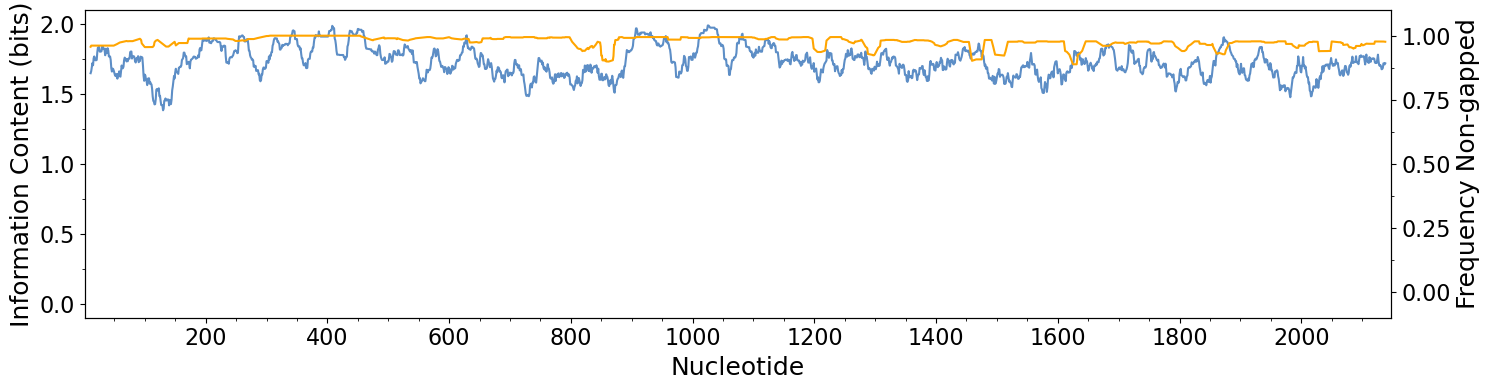

In [27]:
fig, ax1 = plt.subplots(figsize=(15, 4))

# Plot conservation
ax1.plot(df_HOTAIR_exons_combined["real_nt"], df_HOTAIR_exons_combined["info_rolling"], linewidth=1.5, color="#5D8EC6", label="Information Content (bits)")
ax1.set_xlabel("Nucleotide", fontsize=18)
ax1.set_ylabel("Information Content (bits)", fontsize=18)
ax1.set_xlim(1, 2148)
ax1.set_ylim(-0.1, 2.1)
# ax1.set_xlim(0,1046)

# Plot frequency non-gapped
ax2 = ax1.twinx()
ax2.plot(df_HOTAIR_exons_combined["real_nt"], df_HOTAIR_exons_combined["freqnongap_rolling"], linewidth=1.5, color="Orange", label="Frequency Non-gapped")
ax2.set_ylabel("Frequency Non-gapped", fontsize=18)
ax2.set_ylim(-0.1, 1.1)

# Ticks
ax1.tick_params(axis='x', labelsize=16)
ax1.tick_params(axis='y', labelsize=16)
ax2.tick_params(axis='y', labelsize=16)
ax1.xaxis.set_major_locator(MultipleLocator(200))  # major ticks
ax1.xaxis.set_minor_locator(MultipleLocator(50))  # minor ticks
ax1.yaxis.set_minor_locator(MultipleLocator(0.25))  # major ticks
ax2.yaxis.set_minor_locator(MultipleLocator(0.125))  # minor ticks

plt.tight_layout()
# plt.savefig("INSERT/PATH/TO/SAVE/HOTAIR_180_IC_FNG_rolling_w21.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

#### Exploratory Analysis: Plot conservation per structural domain

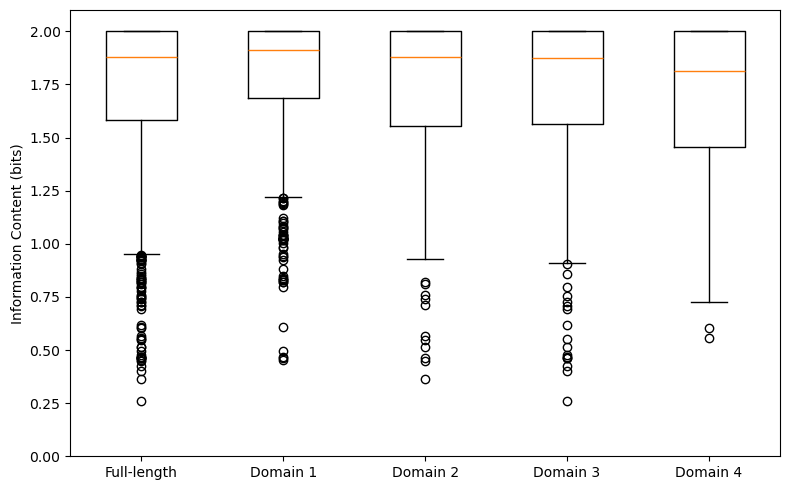

In [28]:
# Define domain ranges
domains = {
    "Full-length": (1, 2148),
    "Domain 1": (1, 530),
    "Domain 2": (531, 1046),
    "Domain 3": (1047, 1747),
    "Domain 4": (1748, 2148),
}

# Extract info(bits) for each domain
data = []
labels = []
for name, (start, end) in domains.items():
    subset = df_HOTAIR_exons_combined[(df_HOTAIR_exons_combined["real_nt"] >= start) & (df_HOTAIR_exons_combined["real_nt"] <= end)]["info(bits)"]
    data.append(subset)
    labels.append(name)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(data, tick_labels=labels, showfliers=True)
ax.set_ylabel("Information Content (bits)")
ax.set_ylim(0, 2.1)
# plt.savefig("INSERT/PATH/TO/SAVE/HOTAIR_IC_per_domain.png", dpi=300, bbox_inches="tight", transparent=True)
plt.tight_layout()
plt.show()


In [29]:
from scipy.stats import mannwhitneyu

full = df_HOTAIR_exons_combined["info(bits)"].dropna()

for name, (start, end) in domains.items():
    domain = df_HOTAIR_exons_combined[(df_HOTAIR_exons_combined["real_nt"] >= start) & 
                                      (df_HOTAIR_exons_combined["real_nt"] <= end)]["info(bits)"].dropna()
    stat, p = mannwhitneyu(domain, full, alternative="two-sided")
    print(f"{name}: U={stat:.1f}, p={p:.4f}")

Full-length: U=2306952.0, p=1.0000
Domain 1: U=624991.5, p=0.0003
Domain 2: U=557427.5, p=0.8331
Domain 3: U=734175.5, p=0.3141
Domain 4: U=390357.5, p=0.0024


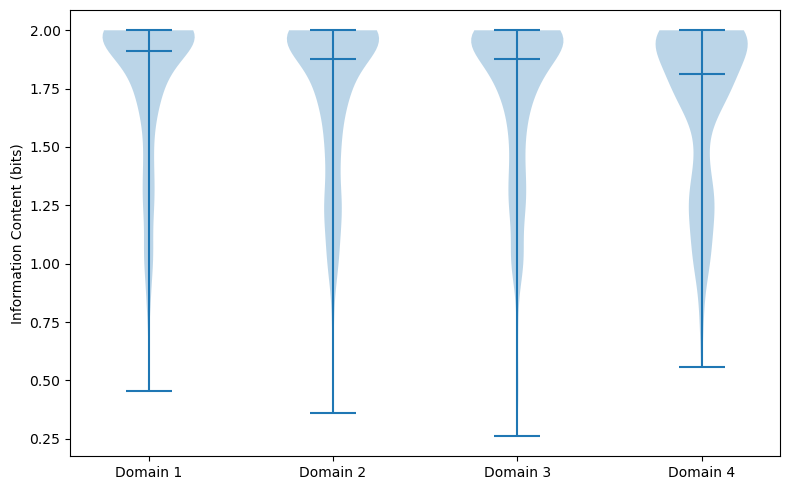

In [30]:
# Define domain ranges
domains = {
    "Domain 1": (1, 530),
    "Domain 2": (531, 1046),
    "Domain 3": (1047, 1747),
    "Domain 4": (1748, 2148),
}

# Extract info(bits) for each domain
data = []
labels = []
for name, (start, end) in domains.items():
    subset = df_HOTAIR_exons_combined[(df_HOTAIR_exons_combined["real_nt"] >= start) & (df_HOTAIR_exons_combined["real_nt"] <= end)]["info(bits)"]
    data.append(subset)
    labels.append(name)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.violinplot(data, positions=range(1, len(data)+1), showmedians=True)
ax.set_xticks(range(1, 5))
ax.set_xticklabels(labels)
ax.set_ylabel("Information Content (bits)")
plt.tight_layout()
plt.show()


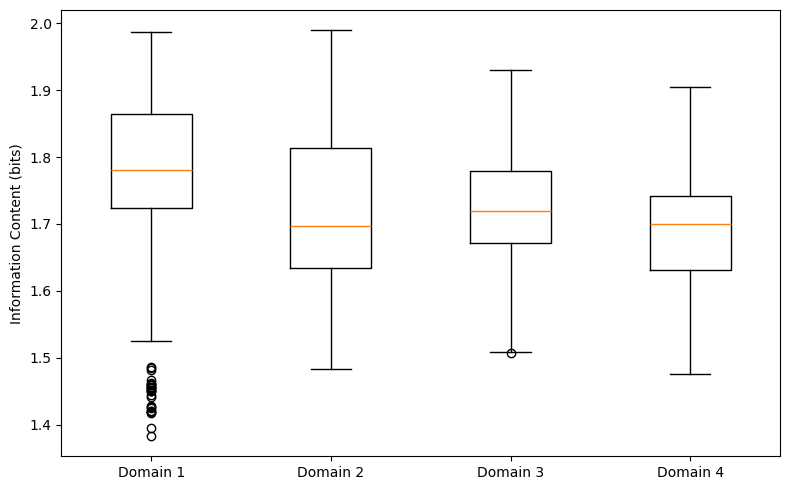

In [31]:
# Define domain ranges
domains = {
    "Domain 1": (1, 530),
    "Domain 2": (531, 1046),
    "Domain 3": (1047, 1747),
    "Domain 4": (1748, 2148),
}

# Extract info(bits) for each domain
data = []
labels = []
for name, (start, end) in domains.items():
    # Must drop NaN values for boxplot
    subset = df_HOTAIR_exons_combined[(df_HOTAIR_exons_combined["real_nt"] >= start) & (df_HOTAIR_exons_combined["real_nt"] <= end)]["info_rolling"].dropna()
    data.append(subset)
    labels.append(name)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(data, tick_labels=labels)
ax.set_ylabel("Information Content (bits)")
plt.tight_layout()
plt.show()


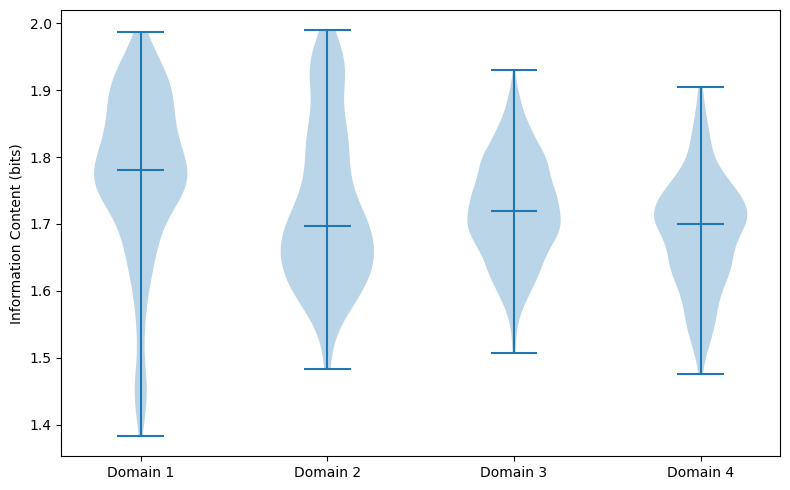

In [32]:
# Define domain ranges
domains = {
    "Domain 1": (1, 530),
    "Domain 2": (531, 1046),
    "Domain 3": (1047, 1747),
    "Domain 4": (1748, 2148),
}

# Extract info(bits) for each domain
data = []
labels = []
for name, (start, end) in domains.items():
    # Must drop NaN values for boxplot
    subset = df_HOTAIR_exons_combined[(df_HOTAIR_exons_combined["real_nt"] >= start) & (df_HOTAIR_exons_combined["real_nt"] <= end)]["info_rolling"].dropna()
    data.append(subset)
    labels.append(name)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.violinplot(data, positions=range(1, len(data)+1), showmedians=True)
ax.set_xticks(range(1, 5))
ax.set_xticklabels(labels)
ax.set_ylabel("Information Content (bits)")
plt.tight_layout()
plt.show()


## Step 3. Concatenate MSA

In [34]:
def merge_alignments(files, filetype):
    # Read all alignments
    alns = [AlignIO.read(f, filetype) for f in files] # list of alignment objects, each containing sequence records
    
    # Index each alignment by sequence ID
    dicts = [{rec.id: rec for rec in aln} for aln in alns] # keys = sequence ID, values = sequence record; list of dictionaries corresponding to each alignment
    
    # Get common IDs from first dictionary
    all_ids = list(dicts[0].keys())
    
    # Concatenate sequences by matching ID
    merged_records = []
    for seq_id in all_ids:
        combined_seq = "".join(str(d[seq_id].seq).upper() for d in dicts) # single string of concatenated sequences from all dictionaries
        new_rec = SeqRecord(Seq(combined_seq), id=seq_id, description="") # create new record with the ID and concatenated sequence
        merged_records.append(new_rec)
    
    return MultipleSeqAlignment(merged_records)

In [36]:
files = ["Data_input/Bioinformatics_Pipeline/Step_2_Scaffold_Validation/2.2_MSAs_of_Exons_on_Same_Scaffold/HOTAIR_exons2-4_MSA_same_scaffold.aln", "Data_input/Bioinformatics_Pipeline/Step_2_Scaffold_Validation/2.2_MSAs_of_Exons_on_Same_Scaffold/HOTAIR_exons5-6_MSA_same_scaffold_subalign.aln", "Data_input/Bioinformatics_Pipeline/Step_2_Scaffold_Validation/2.2_MSAs_of_Exons_on_Same_Scaffold/HOTAIR_exon7_MSA_same_scaffold.aln"]
merged = merge_alignments(files, filetype="clustal")
AlignIO.write(merged, "Data_input/Bioinformatics_Pipeline/Step_3_Concatenate_MSA/HOTAIR_exons2-7_MSA_concatenated.fasta", "fasta")

1

### Remove Large Gaps

In [37]:
human_id = "hHOTAIR"
human_rec = [rec for rec in merged if rec.id == human_id][0] # select human sequence record

# Find columns where human has a stretch of consecutive gaps > 1,000 but keep all other indels/gaps
seq = str(human_rec.seq)
long_gap_positions = set()
for m in re.finditer(r"-{1000,}", seq):
    long_gap_positions.update(range(m.start(), m.end()))
# keep everything except those positions
keep_cols = [i for i in range(len(seq)) if i not in long_gap_positions]

# Filter all sequences to keep only those columns
filtered_records = []
for rec in merged:
    new_seq = "".join(str(rec.seq)[i] for i in keep_cols)
    filtered_records.append(SeqRecord(Seq(new_seq), id=rec.id, description=""))

filtered = MultipleSeqAlignment(filtered_records)
AlignIO.write(filtered, "Data_input/Bioinformatics_Pipeline/Step_3_Concatenate_MSA/HOTAIR_full_MSA.fasta", "fasta")

1

**This is the final MSA used for all subsequent steps: HOTAIR_full_MSA.fasta**

## Step 4. Divergence Group MSAs

Primate alignments were extracted for each divergence group from the final alignment in **Step 3.** Human HOTAIR is included with each alignment. Then, columns were removed that had gaps present in all species (_processed). Both of these alignments (before and after gap removal) are included in their corresponding subfolders. This was done in UGENE (v52.0).

Human and mouse were aligned separately with the Clustal Omega webserver.

## Step 5. Clustering

A clustering level of 95% was chosen as the example for subsequent analyses.

Note: CD-HIT-EST and MAFFT must be installed in the same environment as this Jupyter notebook.

### Clustering

In [39]:
# Function to extract sequences from MSA since CD-HIT clusters based on raw sequences
def extract_sequences(input_fasta, output_fasta):

    records = []

    for rec in SeqIO.parse(input_fasta, "fasta"):

        ungapped = str(rec.seq).replace("-", "")

        records.append(SeqRecord(Seq(ungapped), id=rec.id, description=""))

    SeqIO.write(records, output_fasta, "fasta")

In [40]:
extract_sequences("Data_input/Bioinformatics_Pipeline/Step_3_Concatenate_MSA/HOTAIR_full_MSA.fasta", "Data_input/Bioinformatics_Pipeline/Step_5_Clustering/HOTAIR_full_MSA_extract_sequences.fasta")


In [41]:
# 95% clustering
!cd-hit-est -i Data_input/Bioinformatics_Pipeline/Step_5_Clustering/HOTAIR_full_MSA_extract_sequences.fasta -o Data_input/Bioinformatics_Pipeline/Step_5_Clustering/Full_MSA_clustered95/HOTAIR_full_MSA_clustered95.fasta -c 0.95 -n 8


Program: CD-HIT, V4.8.1 (+OpenMP), Apr 24 2025, 21:58:32
Command: cd-hit-est -i
         Data_input/Bioinformatics_Pipeline/Step_5_Clustering/HOTAIR_full_MSA_extract_sequences.fasta
         -o
         Data_input/Bioinformatics_Pipeline/Step_5_Clustering/Full_MSA_clustered95/HOTAIR_full_MSA_clustered95.fasta
         -c 0.95 -n 8

Started: Fri May 15 15:23:41 2026
                            Output                              
----------------------------------------------------------------
total seq: 180
longest and shortest : 2539 and 1313
Total letters: 409948
Sequences have been sorted

Approximated minimal memory consumption:
Sequence        : 0M
Buffer          : 1 X 18M = 18M
Table           : 1 X 1M = 1M
Miscellaneous   : 0M
Total           : 19M

Table limit with the given memory limit:
Max number of representatives: 336194
Max number of word counting entries: 97519162

comparing sequences from          0  to        180

      180  finished         28  clusters

Approximated

**Important: Before realigning, check the .clstr output file from CD-HIT-EST to ensure hHOTAIR is present. If not, replace the sequence that was chosen from the cluster containing hHOTAIR with hHOTAIR itself.**

In [42]:
# Re-align
!mafft --auto --reorder --clustalout Data_input/Bioinformatics_Pipeline/Step_5_Clustering/Full_MSA_clustered95/HOTAIR_full_MSA_clustered95.fasta > Data_input/Bioinformatics_Pipeline/Step_5_Clustering/Full_MSA_clustered95/HOTAIR_full_MSA_clustered95_aligned.aln


outputhat23=16
treein = 0
compacttree = 0
stacksize: 8176 kb
generating a scoring matrix for nucleotide (dist=200) ... done
All-to-all alignment.
tbfast-pair (nuc) Version 7.526
alg=L, model=DNA200 (2), 2.00 (6.00), -0.10 (-0.30), noshift, amax=0.0
0 thread(s)

outputhat23=16
Loading 'hat3.seed' ... 
done.
Writing hat3 for iterative refinement
generating a scoring matrix for nucleotide (dist=200) ... done
Gap Penalty = -1.53, +0.00, +0.00
tbutree = 1, compacttree = 0
Constructing a UPGMA tree ... 
   20 / 28
done.

Progressive alignment ... 
STEP    14 /27 
Reallocating..done. *alloclen = 6144
STEP    27 /27 
done.
tbfast (nuc) Version 7.526
alg=A, model=DNA200 (2), 1.53 (4.59), -0.00 (-0.00), noshift, amax=0.0
1 thread(s)

minimumweight = 0.000010
autosubalignment = 0.000000
nthread = 0
randomseed = 0
blosum 62 / kimura 200
poffset = 0
niter = 16
sueff_global = 0.100000
nadd = 16
Loading 'hat3' ... done.
generating a scoring matrix for nucleotide (dist=200) ... done

   20 / 28
Segmen

### Plot Conservation for Clustered Alignment

In [43]:
!esl-alistat --icinfo Data_input/Bioinformatics_Pipeline/Step_5_Clustering/Full_MSA_clustered95/HOTAIR_full_MSA_clustered95_aligned_icinfo.txt Data_input/Bioinformatics_Pipeline/Step_5_Clustering/Full_MSA_clustered95/HOTAIR_full_MSA_clustered95_aligned.aln


Alignment number:    1
Format:              Clustal
Number of sequences: 28
Alignment length:    2830
Total # residues:    63760
Smallest:            1384
Largest:             2539
Average length:      2277.1
Average identity:    84%
//
# Information content data saved to file Data_input/Bioinformatics_Pipeline/Step_5_Clustering/Full_MSA_clustered95/HOTAIR_full_MSA_clustered95_aligned_icinfo.txt.


In [44]:
# Warning: Remove '//' in icinfo.txt file before proceeding

In [45]:
alignment_file = "Data_input/Bioinformatics_Pipeline/Step_5_Clustering/Full_MSA_clustered95/HOTAIR_full_MSA_clustered95_aligned.aln"
icinfo_file = "Data_input/Bioinformatics_Pipeline/Step_5_Clustering/Full_MSA_clustered95/HOTAIR_full_MSA_clustered95_aligned_icinfo.txt"
df_HOTAIR_95 = map_ic_to_reference(alignment_file, icinfo_file)
window = 21  # must be odd for symmetric windows
df_HOTAIR_95["info_rolling"] = df_HOTAIR_95["info(bits)"].rolling(window, center=True).mean()
df_HOTAIR_95["freqnongap_rolling"] = df_HOTAIR_95["freqnongap"].rolling(window, center=True).mean()

In [46]:
df_HOTAIR_95.tail(10)

,alnpos,freqnongap,info(bits),ref_nt,info_rolling,freqnongap_rolling
2820,2821,1.0,1.014772,2139,NaN,NaN
2821,2822,1.0,1.777715,2140,NaN,NaN
2822,2823,1.0,2.000000,2141,NaN,NaN
2823,2824,1.0,1.408327,2142,NaN,NaN
2824,2825,1.0,2.000000,2143,NaN,NaN
2825,2826,1.0,2.000000,2144,NaN,NaN
2826,2827,1.0,2.000000,2145,NaN,NaN
2827,2828,1.0,2.000000,2146,NaN,NaN
2828,2829,1.0,2.000000,2147,NaN,NaN
2829,2830,1.0,2.000000,2148,NaN,NaN


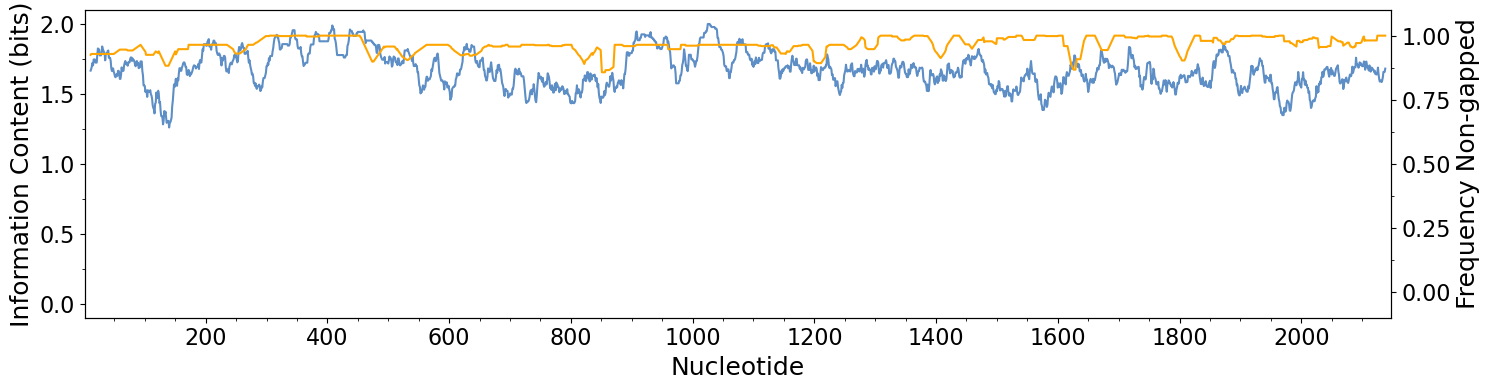

In [47]:
fig, ax1 = plt.subplots(figsize=(15, 4))

# Plot conservation
ax1.plot(df_HOTAIR_95["ref_nt"], df_HOTAIR_95["info_rolling"], linewidth=1.5, color="#5D8EC6", label="Information Content (bits)")
ax1.set_xlabel("Nucleotide", fontsize=18)
ax1.set_ylabel("Information Content (bits)", fontsize=18)
ax1.set_xlim(1, 2148)
ax1.set_ylim(-0.1, 2.1)
# ax1.set_xlim(0,1046)

# Plot frequency non-gapped
ax2 = ax1.twinx()
ax2.plot(df_HOTAIR_95["ref_nt"], df_HOTAIR_95["freqnongap_rolling"], linewidth=1.5, color="Orange", label="Frequency Non-gapped")
ax2.set_ylabel("Frequency Non-gapped", fontsize=18)
ax2.set_ylim(-0.1, 1.1)

# Ticks
ax1.tick_params(axis='x', labelsize=16)
ax1.tick_params(axis='y', labelsize=16)
ax2.tick_params(axis='y', labelsize=16)
ax1.xaxis.set_major_locator(MultipleLocator(200))  # major ticks
ax1.xaxis.set_minor_locator(MultipleLocator(50))  # minor ticks
ax1.yaxis.set_minor_locator(MultipleLocator(0.25))  # major ticks
ax2.yaxis.set_minor_locator(MultipleLocator(0.125))  # minor ticks

plt.tight_layout()
# plt.savefig("INSERT/PATH/TO/SAVE/HOTAIR_cluster95_IC_FNG_rolling_w21.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

## Step 6. Covariation Analysis

Note: First, activate environment with rscape installed!

Examples are shown for the 95% clustered full-length and Domain 3 subalignments.

Notes:
- A "*" indicates that the base pair is predicted in the given secondary structure
- The position numbers (left_pos and right_pos) correspond to the number of characters in the gapped sequence, including gaps. The function **process_rscape_positions** determines the correct nt position in the ungapped sequence.

### Full-length MSA (95% clustering)

In [48]:
# Convert to stockholm
!esl-reformat stockholm Data_input/Bioinformatics_Pipeline/Step_5_Clustering/Full_MSA_clustered95/HOTAIR_full_MSA_clustered95_aligned.aln > Data_input/Bioinformatics_Pipeline/Step_6_Covariation_Analysis/6.1_Prepare_MSAs_with_SS/HOTAIR_full_MSA_clustered95_SS_Preparation/HOTAIR_full_MSA_clustered95_aligned.sto


In [2]:
# Try R-scape without windows or secondary structure
!R-scape --RAFSp --nofigures Data_input/Bioinformatics_Pipeline/Step_6_Covariation_Analysis/6.1_Prepare_MSAs_with_SS/HOTAIR_full_MSA_clustered95_SS_Preparation/HOTAIR_full_MSA_clustered95_aligned.sto

# R-scape :: RNA Structural Covariation Above Phylogenetic Expectation
# R-scape 0.2.1 (February 2016)
# Copyright (C) 2016 Howard Hughes Medical Institute.
# Freely distributed under the GNU General Public License (GPLv3).
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# MSA HOTAIR_full_MSA_clustered95_aligned_1 nseq 28 (28) alen 2174 (2830) avgid 85.35 (84.07) nbpairs 0 (0)
# Method Target_E-val [cov_min,conv_max] [FP | TP True Found | Sen PPV F] 
# RAFSp    0.05         [-0.71,1.21]     [0 | 0 0 0 | 0.00 0.00 0.00] 
#       left_pos       right_pos        score   E-value
#------------------------------------------------------------


Next, add the secondary structure to the stockholm file using the included scripts.

In [3]:
# Try R-scape with a window scanning approach
!R-scape --RAFSp --window 500 --slide 100 --nofigures Data_input/Bioinformatics_Pipeline/Step_6_Covariation_Analysis/6.1_Prepare_MSAs_with_SS/HOTAIR_full_MSA_clustered95_SS_Preparation/HOTAIR_full_MSA_clustered95_aligned_SS.sto


# R-scape :: RNA Structural Covariation Above Phylogenetic Expectation
# R-scape 0.2.1 (February 2016)
# Copyright (C) 2016 Howard Hughes Medical Institute.
# Freely distributed under the GNU General Public License (GPLv3).
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# MSA HOTAIR_full_MSA_clustered95_aligned_SS_1_1-500 nseq 28 (28) alen 458 (500) avgid 88.83 (87.94) nbpairs 123 (123)
# Method Target_E-val [cov_min,conv_max] [FP | TP True Found | Sen PPV F] 
# RAFSp    0.05         [-0.71,0.99]     [0 | 0 123 0 | 0.00 0.00 0.00] 
#       left_pos       right_pos        score   E-value
#------------------------------------------------------------
# MSA HOTAIR_full_MSA_clustered95_aligned_SS_1_101-600 nseq 28 (28) alen 464 (500) avgid 89.12 (88.23) nbpairs 100 (100)
# Method Target_E-val [cov_min,conv_max] [FP | TP True Found | Sen PPV F] 
# RAFSp    0.05         [-0.74,0.99]     [0 | 0 100 0 | 0.00 0.00 0.00] 
#       left_pos       right_pos        score   

In [8]:
# Process R-scape positions to convert to correct nucleotide in hHOTAIR
gapped_sequence = "GACUCGCCUGUGCUC-UGGAGCUU-----GAUCCGAAAGCUUCCACAGUGAGGACU-GCUCCGUGGGGGUAAGA-GAGCACCAGGCACUGAGGCCUGGGAGUUCCACAGACCAACACCC-CUGCUCCUGGCGGCUCC----CACCCGGGGCUUAGAC----CCUCAGGUCCCUAAU----AUCCCGGAGGUGCUCUCAAUCAGAAAGGUCCUGCUCCGCUUCGCAGUGGAAU-GGAACGGAUUUAGAAGCCUGCAGUAGGGGAGUGG-GGAGUGGAGAGAGGGAGCCCAGAGUUACAGACGGCGGCGAGAGGAAGGA------GGGGCG----UCUUUA-UUUUUUUAAGGCCCCAAAGAGU--CUGAUGUUUACAAGACCAGAAAUGCCACGGCCGCGUCCUGGCAGAGA-AAAGGCUGAAAUGGAGGACCGGCGCCUUCCUUAUAAGUAUGCACAUUGG-----CGAG-------AGAAUUAAGUGCUGCAACCUAAACCAGCAAUUACACCCAAGCUCGUUGGGGCCUAAGCCAGUACCGACCUGGUAGAAAAAGCAACCACGAAGCUAGAG--AGAGAGCCAGAGGAGGGAAGAGAGCGCCAGACGAAGGU--------GAAAGCGAACCACGC----AGAGAAAU-----GCAGGCAAGGGAGCAAGGCGGCAGUUC---CCGGAACAAACGUGGCAGAGGGCAAGACGGGCACUCACAGACAGAGGUUUAUG----UA---UUUUUA----UUUUUUAAAAUCUGAUUUGGUGUUCCAUGAGGAAAAGGGAAAAUCUAGGGAACGGG-----AGUACAGAGAGAAUAAUCCGGGUCCUAGCUCGCCACAUGAACGCCC------AGAGAACGCUGGAAAAACCUGAGC-GGGUGCCGGG---GCA------GCACCCGG------CUCGGGUCAGCCACUGCCCCACAC----------CGGGCCCACCAAGCCCCGCCCCUCGC-GGCCACCGGGGCUUCCUUGCUC-UUCUUAUCAUCUCCAUCUUUAUGAUGAGGCUUGUUAACAAGACCAGAGAGCUGGCCAAGCACCUCUAUCUCAGCCGCGCCCGCUCAGCCGAGCAGCG------GUCGGUGG-GGGGACUGGGAGGCGCUAAUUAAUUGAUUCCUUUGGACUGUAAAAUAUGGCGGCGUCUACACGGAACCCAUGGACUCAUAAACAAUAUAUCUGUUGGGCGUGAGUGCACUGUCUCUCAAAUAAUUUUUCCAUAGGCAAAUGUCAGAGGGUUCUGGAUUUUUAGUUGCUAAGGAAAGAUCCAAAUGGGACCAAU-UUUAGGAGGCCCAAACA---GAGUCCGUUCAGUGUCAGAAAAUGCUUCCCCAAA-GGGUUGGCAGUGUGUUUUGUUGG------------------------------------------AAAAAAGCUUGGGUUAUAGGAAAGCCUUUCCCUGCUACUUGUGUAGACCCAGCCCAAUUUAAGAAUUACAAGGAAGCGAAGG----GGUUGUGUAGGCCGGAAGCCUCUCUGUCCC-------GGCUGGAUGCAGGGGACUUGAGCUGCU----CCGGAAUUUGAGAGGAACAUAGAAGCAAAGGUCCAGCCUUUGCUUCGUGCUGAUUCCUAGACUUAAGAUUCAAAAACAAAUUUU-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------UAAAAGUGAAAC----CAGCCCUAGCCUUUGGAAGCUCUUGAAGGUUCAGCACCCACCC--AGGAAUCCACC----------------------UGCCUGUUACACGCCUCUCCAAGACACAGUGGCACCGC-UUUUCUAACUGGCAGCACAGAGCAACUCUAUAAUAUGCUUAUAUUAGGUCUAGAAGAAUGCAUCUUGAGACACAU-GGGUAACCUAA-UUAUAUAAUGCUUGUUCCAUACA--GGAGUGAUUAUGCAGUG-GGACCCUGCUGCAAACGGGACUUUGCACUCUAAAUAUAGG------CCCCAGCUUGGGACAAAAGUUGCAGUAGAAAAAUAGACAUAGGAGAACACUUAAAUAAGUGAUG--------CAUGUAGACAC-AGAAGGGGUAUUUAAAAGACAGAAAUAAUAGAAGUACAGAAGAACAG---AAAAAAAA-UCAGCAGAUGGAGAUUACCAUUCCCAAUGC-----CUGAACUUCC--UCCUGCUA------UUAAGAUUGCUAGAGAAUUGUGUCUUA----AACAGUUCAUGAACCCAGAAG----AACGCAAU-----------------------UUCAAUGUAUUUAGUACA------CACAC-------AGUAUGUAUAUAAACACAACUCACAGA--AUAUA-UUUUCCAUAC-AUUGGGUAGGUAUGCACUUUGUGUAUAUAUAAU------AAUGUAUUUUCCAUGCAG---UUUUAAAAUGUAGAUA----UAUUAAUAUCUGGAUGCAUUUUC"
process_rscape_positions("Data_input/Bioinformatics_Pipeline/Step_6_Covariation_Analysis/6.3_R-scape_Results/RAFSp_results_HOTAIR_full_MSA_clustered95_window500_slide100_SS.txt", gapped_sequence, "Data_input/Bioinformatics_Pipeline/Step_6_Covariation_Analysis/6.3_R-scape_Results/RAFSp_results_HOTAIR_full_MSA_clustered95_window500_slide100_SS_processed.txt")


Results saved to Data_input/Bioinformatics_Pipeline/Step_6_Covariation_Analysis/6.3_R-scape_Results/RAFSp_results_HOTAIR_full_MSA_clustered95_window500_slide100_SS_processed.txt
Processed 8 position pairs


,left_pos,right_pos,left_pos_ungapped,right_pos_ungapped,nucleotide
0,407,419,371,382,A:U
1,326,353,297,319,G:C
2,1492,1531,1317,1352,A:U
3,1624,1634,1434,1444,A:U
4,2052,2061,1497,1502,G:C
5,2065,2076,1506,1517,C:G
6,2106,2139,1545,1556,A:U
7,2107,2116,1546,1555,G:C


In [9]:
# Try R-scape with GTp
!R-scape --GTp --window 500 --slide 100 --nofigures Data_input/Bioinformatics_Pipeline/Step_6_Covariation_Analysis/6.1_Prepare_MSAs_with_SS/HOTAIR_full_MSA_clustered95_SS_Preparation/HOTAIR_full_MSA_clustered95_aligned_SS.sto


# R-scape :: RNA Structural Covariation Above Phylogenetic Expectation
# R-scape 0.2.1 (February 2016)
# Copyright (C) 2016 Howard Hughes Medical Institute.
# Freely distributed under the GNU General Public License (GPLv3).
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# MSA HOTAIR_full_MSA_clustered95_aligned_SS_1_1-500 nseq 28 (28) alen 458 (500) avgid 88.83 (87.94) nbpairs 123 (123)
# Method Target_E-val [cov_min,conv_max] [FP | TP True Found | Sen PPV F] 
# GTp    0.05         [-9.82,26.57]     [0 | 0 123 0 | 0.00 0.00 0.00] 
#       left_pos       right_pos        score   E-value
#------------------------------------------------------------
# MSA HOTAIR_full_MSA_clustered95_aligned_SS_1_101-600 nseq 28 (28) alen 464 (500) avgid 89.12 (88.23) nbpairs 100 (100)
# Method Target_E-val [cov_min,conv_max] [FP | TP True Found | Sen PPV F] 
# GTp    0.05         [-9.82,28.69]     [0 | 0 100 0 | 0.00 0.00 0.00] 
#       left_pos       right_pos        score   E-

### Subalignment of Domain 3 (95% clustering)

This was extracted from the 95% clustered alignment of full-length HOTAIR. This was converted to stockholm format and the secondary structure was added as before.

In [10]:
!R-scape --RAFSp --window 500 --slide 100 --nofigures Data_input/Bioinformatics_Pipeline/Step_6_Covariation_Analysis/6.1_Prepare_MSAs_with_SS/HOTAIR_full_MSA_clustered95_D3_SS_Preparation/HOTAIR_full_MSA_clustered95_D3_SS.sto


# R-scape :: RNA Structural Covariation Above Phylogenetic Expectation
# R-scape 0.2.1 (February 2016)
# Copyright (C) 2016 Howard Hughes Medical Institute.
# Freely distributed under the GNU General Public License (GPLv3).
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# MSA HOTAIR_full_MSA_clustered95_D3_SS_1_1-500 nseq 28 (28) alen 438 (500) avgid 86.51 (86.06) nbpairs 86 (86)
# Method Target_E-val [cov_min,conv_max] [FP | TP True Found | Sen PPV F] 
# RAFSp    0.05         [-0.68,1.08]     [0 | 1 86 1 | 1.16 100.00 2.30] 
#       left_pos       right_pos        score   E-value
#------------------------------------------------------------
*	     318	     357	0.77	0.044096
# MSA HOTAIR_full_MSA_clustered95_D3_SS_1_101-600 nseq 28 (28) alen 343 (500) avgid 85.26 (84.20) nbpairs 54 (54)
# Method Target_E-val [cov_min,conv_max] [FP | TP True Found | Sen PPV F] 
# RAFSp    0.05         [-0.69,1.07]     [0 | 1 54 1 | 1.85 100.00 3.64] 
#       left_pos       rig

In [11]:
!R-scape --RAFSp --window 300 --slide 100 --nofigures Data_input/Bioinformatics_Pipeline/Step_6_Covariation_Analysis/6.1_Prepare_MSAs_with_SS/HOTAIR_full_MSA_clustered95_D3_SS_Preparation/HOTAIR_full_MSA_clustered95_D3_SS.sto


# R-scape :: RNA Structural Covariation Above Phylogenetic Expectation
# R-scape 0.2.1 (February 2016)
# Copyright (C) 2016 Howard Hughes Medical Institute.
# Freely distributed under the GNU General Public License (GPLv3).
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# MSA HOTAIR_full_MSA_clustered95_D3_SS_1_1-300 nseq 28 (28) alen 253 (300) avgid 86.52 (86.10) nbpairs 47 (47)
# Method Target_E-val [cov_min,conv_max] [FP | TP True Found | Sen PPV F] 
# RAFSp    0.05         [-0.65,1.04]     [0 | 1 47 1 | 2.13 100.00 4.17] 
#       left_pos       right_pos        score   E-value
#------------------------------------------------------------
*	     279	     298	0.74	0.046879
# MSA HOTAIR_full_MSA_clustered95_D3_SS_1_101-400 nseq 28 (28) alen 242 (300) avgid 85.33 (84.85) nbpairs 28 (28)
# Method Target_E-val [cov_min,conv_max] [FP | TP True Found | Sen PPV F] 
# RAFSp    0.05         [-0.69,1.05]     [0 | 3 28 3 | 10.71 100.00 19.35] 
#       left_pos       r

In [12]:
!R-scape --GTp --window 500 --slide 100 --nofigures Data_input/Bioinformatics_Pipeline/Step_6_Covariation_Analysis/6.1_Prepare_MSAs_with_SS/HOTAIR_full_MSA_clustered95_D3_SS_Preparation/HOTAIR_full_MSA_clustered95_D3_SS.sto


# R-scape :: RNA Structural Covariation Above Phylogenetic Expectation
# R-scape 0.2.1 (February 2016)
# Copyright (C) 2016 Howard Hughes Medical Institute.
# Freely distributed under the GNU General Public License (GPLv3).
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# MSA HOTAIR_full_MSA_clustered95_D3_SS_1_1-500 nseq 28 (28) alen 438 (500) avgid 86.51 (86.06) nbpairs 86 (86)
# Method Target_E-val [cov_min,conv_max] [FP | TP True Found | Sen PPV F] 
# GTp    0.05         [-9.82,26.42]     [0 | 0 86 0 | 0.00 0.00 0.00] 
#       left_pos       right_pos        score   E-value
#------------------------------------------------------------
# MSA HOTAIR_full_MSA_clustered95_D3_SS_1_101-600 nseq 28 (28) alen 343 (500) avgid 85.26 (84.20) nbpairs 54 (54)
# Method Target_E-val [cov_min,conv_max] [FP | TP True Found | Sen PPV F] 
# GTp    0.05         [-9.81,26.94]     [0 | 0 54 0 | 0.00 0.00 0.00] 
#       left_pos       right_pos        score   E-value
#---------

In [13]:
!R-scape --GTp --window 300 --slide 100 --nofigures Data_input/Bioinformatics_Pipeline/Step_6_Covariation_Analysis/6.1_Prepare_MSAs_with_SS/HOTAIR_full_MSA_clustered95_D3_SS_Preparation/HOTAIR_full_MSA_clustered95_D3_SS.sto


# R-scape :: RNA Structural Covariation Above Phylogenetic Expectation
# R-scape 0.2.1 (February 2016)
# Copyright (C) 2016 Howard Hughes Medical Institute.
# Freely distributed under the GNU General Public License (GPLv3).
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# MSA HOTAIR_full_MSA_clustered95_D3_SS_1_1-300 nseq 28 (28) alen 253 (300) avgid 86.52 (86.10) nbpairs 47 (47)
# Method Target_E-val [cov_min,conv_max] [FP | TP True Found | Sen PPV F] 
# GTp    0.05         [-9.82,23.44]     [0 | 0 47 0 | 0.00 0.00 0.00] 
#       left_pos       right_pos        score   E-value
#------------------------------------------------------------
# MSA HOTAIR_full_MSA_clustered95_D3_SS_1_101-400 nseq 28 (28) alen 242 (300) avgid 85.33 (84.85) nbpairs 28 (28)
# Method Target_E-val [cov_min,conv_max] [FP | TP True Found | Sen PPV F] 
# GTp    0.05         [-9.83,24.15]     [0 | 0 28 0 | 0.00 0.00 0.00] 
#       left_pos       right_pos        score   E-value
#---------

##### Process R-scape positions to convert to correct nucleotide in hHOTAIR

In [14]:
gapped_sequence = "UGGCGGCGUCUACACGGAACCCAUGGACUCAUAAACAAUAUAUCUGUUGGGCGUGAGUGCACUGUCUCUCAAAUAAUUUUUCCAUAGGCAAAUGUCAGAGGGUUCUGGAUUUUUAGUUGCUAAGGAAAGAUCCAAAUGGGACCAAU-UUUAGGAGGCCCAAACA---GAGUCCGUUCAGUGUCAGAAAAUGCUUCCCCAAA-GGGUUGGCAGUGUGUUUUGUUGG------------------------------------------AAAAAAGCUUGGGUUAUAGGAAAGCCUUUCCCUGCUACUUGUGUAGACCCAGCCCAAUUUAAGAAUUACAAGGAAGCGAAGG----GGUUGUGUAGGCCGGAAGCCUCUCUGUCCC-------GGCUGGAUGCAGGGGACUUGAGCUGCU----CCGGAAUUUGAGAGGAACAUAGAAGCAAAGGUCCAGCCUUUGCUUCGUGCUGAUUCCUAGACUUAAGAUUCAAAAACAAAUUUU-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------UAAAAGUGAAAC----CAGCCCUAGCCUUUGGAAGCUCUUGAAGGUUCAGCACCCACCC--AGGAAUCCACC----------------------UGCCUGUUACACGCCUCUCCAAGACACAGUGGCACCGC-UUUUCUAACUGGCAGCACAGAGCAACUCUAUAAUAUGCUUAUAUUAGGUCUAGAAGAAUGCAUCUUGAGACACAU-GGGUAACCUAA-UUAUAUAAUGCUUGUUCCAUACA--GGAGUGAUUAUGCAGUG-GGACCCUGCUGCAAACGGGACUUUGCAC"
df_D3_500 = process_rscape_positions("Data_input/Bioinformatics_Pipeline/Step_6_Covariation_Analysis/6.3_R-scape_Results/RAFSp_results_HOTAIR_full_MSA_clustered95_window500_slide100_SS_D3subalignment.txt", gapped_sequence, "Data_input/Bioinformatics_Pipeline/Step_6_Covariation_Analysis/6.3_R-scape_Results/RAFSp_results_HOTAIR_full_MSA_clustered95_window500_slide100_SS_D3subalignment_processed.txt")


Results saved to Data_input/Bioinformatics_Pipeline/Step_6_Covariation_Analysis/6.3_R-scape_Results/RAFSp_results_HOTAIR_full_MSA_clustered95_window500_slide100_SS_D3subalignment_processed.txt
Processed 8 position pairs


In [15]:
# Offset by 1046nt to correspond to full-length
df_D3_500["left_offset"] = df_D3_500["left_pos_ungapped"] + 1046
df_D3_500["right_offset"] = df_D3_500["right_pos_ungapped"] + 1046
df_D3_500.to_csv("Data_input/Bioinformatics_Pipeline/Step_6_Covariation_Analysis/6.3_R-scape_Results/RAFSp_results_HOTAIR_full_MSA_clustered95_window500_slide100_SS_D3subalignment_processed_offset.txt", sep="\t", index=False)


In [16]:
gapped_sequence = "UGGCGGCGUCUACACGGAACCCAUGGACUCAUAAACAAUAUAUCUGUUGGGCGUGAGUGCACUGUCUCUCAAAUAAUUUUUCCAUAGGCAAAUGUCAGAGGGUUCUGGAUUUUUAGUUGCUAAGGAAAGAUCCAAAUGGGACCAAU-UUUAGGAGGCCCAAACA---GAGUCCGUUCAGUGUCAGAAAAUGCUUCCCCAAA-GGGUUGGCAGUGUGUUUUGUUGG------------------------------------------AAAAAAGCUUGGGUUAUAGGAAAGCCUUUCCCUGCUACUUGUGUAGACCCAGCCCAAUUUAAGAAUUACAAGGAAGCGAAGG----GGUUGUGUAGGCCGGAAGCCUCUCUGUCCC-------GGCUGGAUGCAGGGGACUUGAGCUGCU----CCGGAAUUUGAGAGGAACAUAGAAGCAAAGGUCCAGCCUUUGCUUCGUGCUGAUUCCUAGACUUAAGAUUCAAAAACAAAUUUU-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------UAAAAGUGAAAC----CAGCCCUAGCCUUUGGAAGCUCUUGAAGGUUCAGCACCCACCC--AGGAAUCCACC----------------------UGCCUGUUACACGCCUCUCCAAGACACAGUGGCACCGC-UUUUCUAACUGGCAGCACAGAGCAACUCUAUAAUAUGCUUAUAUUAGGUCUAGAAGAAUGCAUCUUGAGACACAU-GGGUAACCUAA-UUAUAUAAUGCUUGUUCCAUACA--GGAGUGAUUAUGCAGUG-GGACCCUGCUGCAAACGGGACUUUGCAC"
df_D3_300 = process_rscape_positions("Data_input/Bioinformatics_Pipeline/Step_6_Covariation_Analysis/6.3_R-scape_Results/RAFSp_results_HOTAIR_full_MSA_clustered95_window300_slide100_SS_D3subalignment.txt", gapped_sequence, "Data_input/Bioinformatics_Pipeline/Step_6_Covariation_Analysis/6.3_R-scape_Results/RAFSp_results_HOTAIR_full_MSA_clustered95_window300_slide100_SS_D3subalignment_processed.txt")


Results saved to Data_input/Bioinformatics_Pipeline/Step_6_Covariation_Analysis/6.3_R-scape_Results/RAFSp_results_HOTAIR_full_MSA_clustered95_window300_slide100_SS_D3subalignment_processed.txt
Processed 14 position pairs


In [17]:
# Offset by 1046nt to correspond to full-length
df_D3_300["left_offset"] = df_D3_300["left_pos_ungapped"] + 1046
df_D3_300["right_offset"] = df_D3_300["right_pos_ungapped"] + 1046
df_D3_300.to_csv("Data_input/Bioinformatics_Pipeline/Step_6_Covariation_Analysis/6.3_R-scape_Results/RAFSp_results_HOTAIR_full_MSA_clustered95_window300_slide100_SS_D3subalignment_processed_offset.txt", sep="\t", index=False)
